In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import emg_functions

# get user path:
userpath = os.path.expanduser('~')
projectPath = os.path.join(userpath, 'Desktop', 'Projects', 'EFC_learningEMG')

dataPath = os.path.join(projectPath, 'data')
emgPath = os.path.join(dataPath, 'emg')
behaviouralPath = os.path.join(dataPath, 'behavioural')
figPath = os.path.join(projectPath, 'figures')
analysisPath = os.path.join(projectPath, 'analysis')



For EMG there is day1 and day5. Each day we have a single_finger run and 10 chord runs (_1 to _10). For behavioural, day0 they do a pre-training. day2 to day5, they practice only the 4 trained chords.

## preprocess subject

In [ ]:
sn = 100

# Desired EMG channel order (columns of each trial matrix):
channels = ['flx_D1', 'flx_D2', 'flx_D3', 'flx_D4', 'flx_D5',
            'ext_D1', 'ext_D2', 'ext_D3', 'ext_D4', 'ext_D5']

fs_emg = 2148.1481
fs_trigger = 2222.2222
days = [1, 5]
runs = list(range(1, 12))  # 1,2,...,11

rows = []  # will become the subject dataframe (one row per trial)

for day in days:
    for run in runs:
        fname = f'EFC_learningEMG_{sn}_{run:02d}.csv'
        fpath = os.path.join(emgPath, f'day{day}', f'subj{sn}', fname)

        # -------------------- EMG prep (load → trigger → segment → filter) --------------------
        trials = emg_functions.preprocess_emg_run(
            fpath, channels, fs_emg=fs_emg, fs_trigger=fs_trigger, debug=0
        )

        # -------------------- behaviour prep (add fields here) --------------------
        # TODO: load / analyse behaviour for this (sn, day, run) and attach
        # fields onto each trial dict before appending to rows.

        for t in trials:
            rows.append({
                'sn': sn,
                'day': day,
                'run': run,
                'trial': t['trial'],
                'emg': t['emg'],           # (N x 10) preprocessed matrix
                'channels': t['channels'],
                # behaviour fields go here, e.g.:
                # 'RT': ...,
                # 'chordID': ...,
            })

        print(f'EMG - day{day} run={run}: {len(trials)} trials')

df = pd.DataFrame(rows)
print('\nSubject dataframe:')
display(df)
print('example: df.iloc[0]["emg"].shape =', df.iloc[0]['emg'].shape)
print('channels =', df.iloc[0]['channels'])

# save the preprocessed data as pickle in analysis folder:
df.to_pickle(os.path.join(analysisPath, f's{sn}_emg.pkl'))


EMG - day1 run=1: 50 trials
EMG - day1 run=2: 40 trials
EMG - day1 run=3: 40 trials


## testing methods

In [1]:
import numpy as np
from scipy.signal import butter, filtfilt

# Example: Bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_63292/1574997421.py:11: DtypeWarning: Columns (8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(


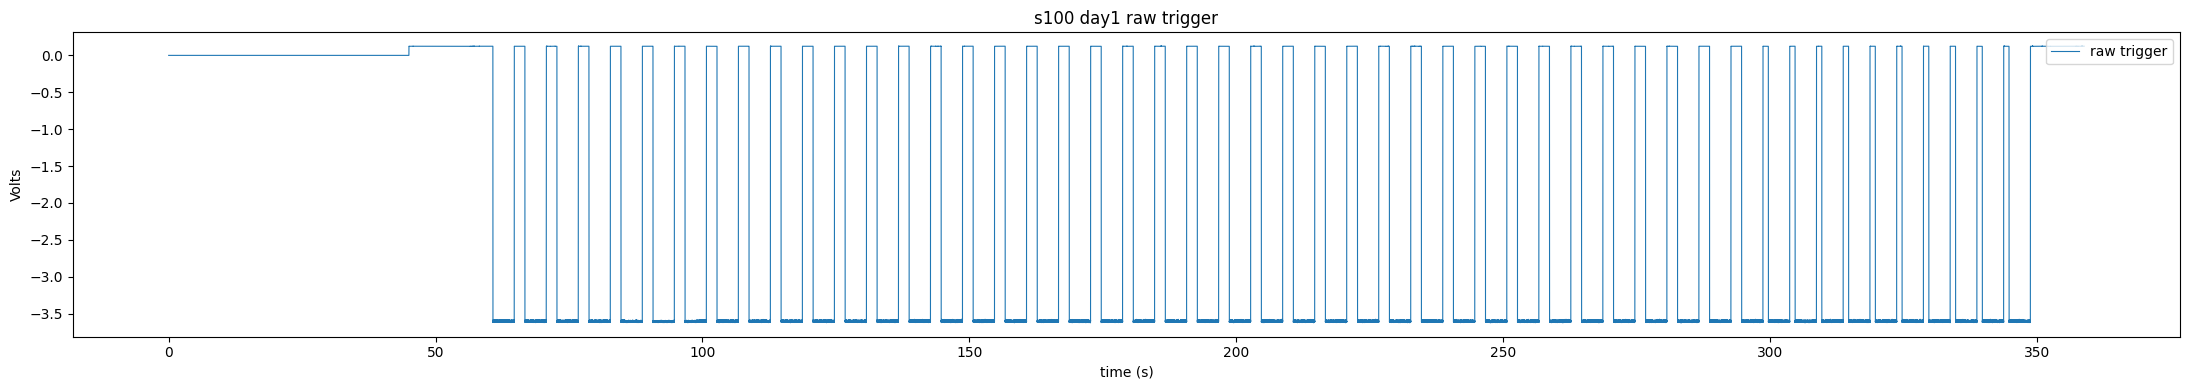

In [3]:
# Debug: raw (unprocessed) trigger for s100 day1
sn = 100
day = 'day1'
fs_trigger = 2222.2222

header = pd.read_csv(
    os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'),
    skiprows=5, nrows=1, header=None,
)
header = header.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
data = pd.read_csv(
    os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'),
    skiprows=8, header=None,
)
data = data.iloc[:, :28]
data.columns = header.iloc[0, :28]
data = data.reset_index(drop=True)

trigger = data['Analog 1 (V)'].values
emg_functions.plot_raw_trigger(trigger, fs=fs_trigger, title=f's{sn} {day} raw trigger')


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_63292/4047046897.py:12: DtypeWarning: Columns (8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'),




======== Trigger Detection Results: ======== 

Polarity: INVERTED (raw negated; idle was high)
Num Rise Trigger = 50
Num Fall Triggers = 50
Two numbers should be equal to the number of trials.

riseThresh=0.60, fallThresh=0.40, min_width_ms=20, start_idx=0

Number of non-positive fall-rise edges = 0
This value should be 0.
Pulse width ms: min=3997.4, median=3998.7, max=4004.6



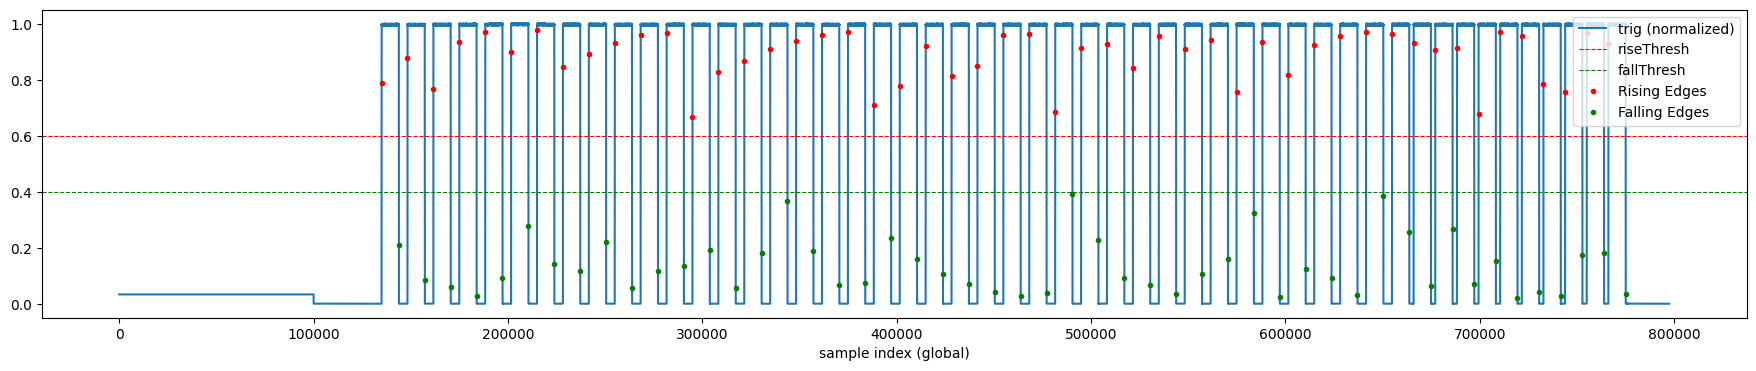

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_63292/4047046897.py:12: DtypeWarning: Columns (8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'),




======== Trigger Detection Results: ======== 

Polarity: INVERTED (raw negated; idle was high)
Num Rise Trigger = 50
Num Fall Triggers = 50
Two numbers should be equal to the number of trials.

riseThresh=0.60, fallThresh=0.40, min_width_ms=20, start_idx=0

Number of non-positive fall-rise edges = 0
This value should be 0.
Pulse width ms: min=3996.5, median=3999.4, max=4002.8



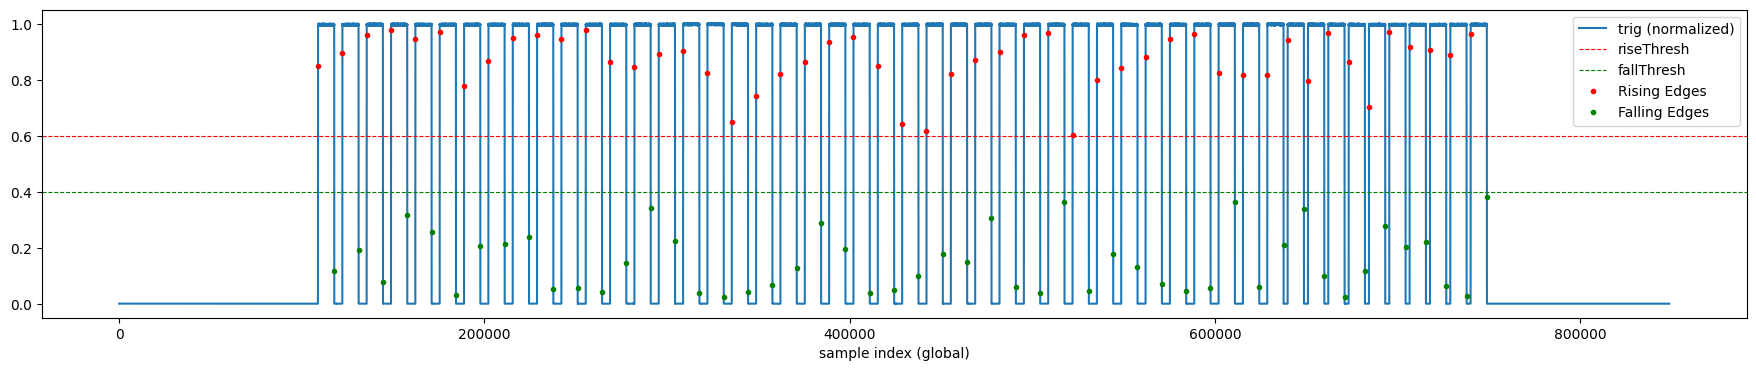

In [20]:
sn = 100

# Prep EMG:
df = {'t'}
days = ['day1', 'day5']
for day in days:
    # ========================= detect trigger signal =========================
    header = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'), 
                         skiprows=5, nrows=1, header=None) 
    # remove extra spaces in header:
    header = header.apply(lambda x: x.str.strip() if x.dtype == "object" else x) 
    data = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'), 
                       skiprows=8, header=None)
    data = data.iloc[:, :28]
    data.columns = header.iloc[0, :28]
    data = data.reset_index(drop=True)

    trigger = data['Analog 1 (V)'].values
    fs_trigger = 2222.2222
    riseIdx, fallIdx = emg_functions.find_trigger_rise_edge(trigger, fs_trigger, riseThresh=0.6, fallThresh=0.4, min_width_ms=20, debug=1)

